# Illicit Bitcoin Detection
## Phase 0: Exploratory Data Analysis

This notebook performs the exploratory data analysis required before any graph construction or modeling work begins. Its purpose is strictly diagnostic: verifying that the raw dataset matches its documented characteristics, quantifying the class imbalance and temporal structure that will drive downstream design decisions, and identifying any anomalies that must be resolved before the data can be trusted. No feature engineering, scaling, or graph construction is performed here; those belong to Phase 1.

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

# Plotting configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Resolve project root and locate config.yaml
PROJECT_ROOT = Path.cwd().parent
config_path = PROJECT_ROOT / "configs" / "config.yaml"

with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Resolve paths directly from configuration
DATA_RAW = PROJECT_ROOT / config["paths"]["raw_data_dir"]
DATA_PROCESSED = PROJECT_ROOT / config["paths"]["processed_data_dir"]
FIGURES_DIR = PROJECT_ROOT / config["paths"]["figures_dir"]

# Ensure output directories exist
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Configuration loaded from: {config_path}")
print(f"Raw Data: {DATA_RAW}")
print(f"Processed Data: {DATA_PROCESSED}")
print(f"Figures: {FIGURES_DIR}")


Configuration loaded from: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/configs/config.yaml
Raw Data: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/data/raw
Processed Data: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/data/processed
Figures: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/outputs/figures


## 1. Raw Data Loading and Integrity Verification

The Elliptic Bitcoin dataset ships as three separate CSV files: a features file (`elliptic_txs_features.csv`), a class label file (`elliptic_txs_classes.csv`), and an edge list (`elliptic_txs_edgelist.csv`). The features file is documented as containing 203,769 rows and 167 columns (transaction ID, time step, and 165 features). Before proceeding, the row and column counts of each loaded file must be checked against these documented figures. A mismatch here is a strong signal of a truncated download, an encoding issue, or a corrupted file, and must be resolved before any further work.

In [11]:
features_path = DATA_RAW / "elliptic_txs_features.csv"

# Inspect the number of columns from the first row
num_total_cols = pd.read_csv(features_path, header=None, nrows=1).shape[1]
n_features = num_total_cols - 2

# Assign explicit column names (tx_id, time_step, feat_1 ... feat_165)
feature_col_names = ["tx_id", "time_step"] + [f"feat_{i}" for i in range(1, n_features + 1)]

df_features = pd.read_csv(
    features_path,
    header=None,
    names=feature_col_names,
    dtype={"tx_id": np.int64, "time_step": np.int32}
)

print(f"Loaded features shape: {df_features.shape}")
assert df_features.shape == (203769, 167), f"Expected shape (203769, 167), got: {df_features.shape}"
print("Features matrix successfully verified (203,769 rows, 165 features + tx_id, time_step).")

Loaded features shape: (203769, 167)
Features matrix successfully verified (203,769 rows, 165 features + tx_id, time_step).


In [12]:
classes_path = DATA_RAW / "elliptic_txs_classes.csv"
edgelist_path = DATA_RAW / "elliptic_txs_edgelist.csv"

df_classes = pd.read_csv(classes_path).rename(columns={"txId": "tx_id"})
df_edges = pd.read_csv(edgelist_path).rename(columns={"txId1": "source", "txId2": "target"})

EXPECTED_NODES = 203769
EXPECTED_EDGES = 234355

print(f"Class labels shape: {df_classes.shape}")
print(f"Edge list shape:    {df_edges.shape}")

if df_classes.shape[0] != EXPECTED_NODES:
    raise ValueError(f"Discrepancy: Expected {EXPECTED_NODES} nodes, found {df_classes.shape[0]}")
print(f"Confirmed: Exactly {EXPECTED_NODES} nodes present in class file.")

if df_edges.shape[0] != EXPECTED_EDGES:
    raise ValueError(f"Discrepancy: Expected {EXPECTED_EDGES} edges, found {df_edges.shape[0]}")
print(f"Confirmed: Exactly {EXPECTED_EDGES} edges present in edge list.")

Class labels shape: (203769, 2)
Edge list shape:    (234355, 2)
Confirmed: Exactly 203769 nodes present in class file.
Confirmed: Exactly 234355 edges present in edge list.


**Findings:** Both raw files matched the documented dataset statistics exactly: 203,769 rows by 167 columns in the features file, 203,769 rows in the class file, and 234,355 rows in the edge list. No truncation, encoding, or corruption issues were detected.

## 2. Class Distribution Analysis

The class label file encodes three categories: licit, illicit, and unknown. The unknown category is documented as constituting the majority of nodes, which is the empirical basis for the transductive semi-supervised design decision already locked into `configs/config.yaml` (unknown nodes participate in message passing but are excluded from the loss computation). This section must produce the exact proportions, not an approximation, since this figure will be cited directly in the portfolio write-up as justification for that design decision.

In [13]:
# Raw format: "1" = illicit, "2" = licit, "unknown" = unknown
class_map = {"1": "illicit", "2": "licit", "unknown": "unknown", 1: "illicit", 2: "licit"}
df_classes["class_label"] = df_classes["class"].map(class_map).fillna(df_classes["class"])

total_counts = df_classes["class_label"].value_counts()
total_props = df_classes["class_label"].value_counts(normalize=True) * 100

overall_dist = pd.DataFrame({
    "Count": total_counts,
    "Overall Proportion (%)": total_props.round(4)
})

# Filter labeled subset (licit / illicit only)
labeled_subset = df_classes[df_classes["class_label"].isin(["licit", "illicit"])]
labeled_counts = labeled_subset["class_label"].value_counts()
labeled_props = labeled_subset["class_label"].value_counts(normalize=True) * 100

labeled_dist = pd.DataFrame({
    "Count": labeled_counts,
    "Labeled Proportion (%)": labeled_props.round(4)
})

print("=== Overall Class Distribution ===")
display(overall_dist)

print("\n=== Labeled Nodes Distribution ===")
display(labeled_dist)

=== Overall Class Distribution ===


,Count,Overall Proportion (%)
class_label,,
unknown,157205,77.1486
licit,42019,20.6209
illicit,4545,2.2305



=== Labeled Nodes Distribution ===


,Count,Labeled Proportion (%)
class_label,,
licit,42019,90.2392
illicit,4545,9.7608


**Findings:** The overall class distribution is 157,205 unknown (77.15%), 42,019 licit (20.62%), and 4,545 illicit (2.23%). Restricted to the labeled subset only, this is 90.24% licit versus 9.76% illicit. These figures empirically justify the transductive design already fixed in `configs/config.yaml`: unknown nodes constitute the large majority of the graph and must remain in the message-passing computation even though they are excluded from the loss.

## 3. Temporal Structure Validation

The dataset spans 49 discrete time steps. The locked temporal split (train: steps 1-30, validation: steps 31-40, test: steps 41-49) assumes that each of these three ranges contains a reasonable density of nodes and, critically, a reasonable density of labeled (non-unknown) nodes. A split range that is disproportionately unknown-labeled would make validation or test metrics unreliable regardless of model quality. This section must plot or tabulate node count and labeled-node count per time step, and explicitly flag any time step that is a statistical outlier relative to its neighbors.

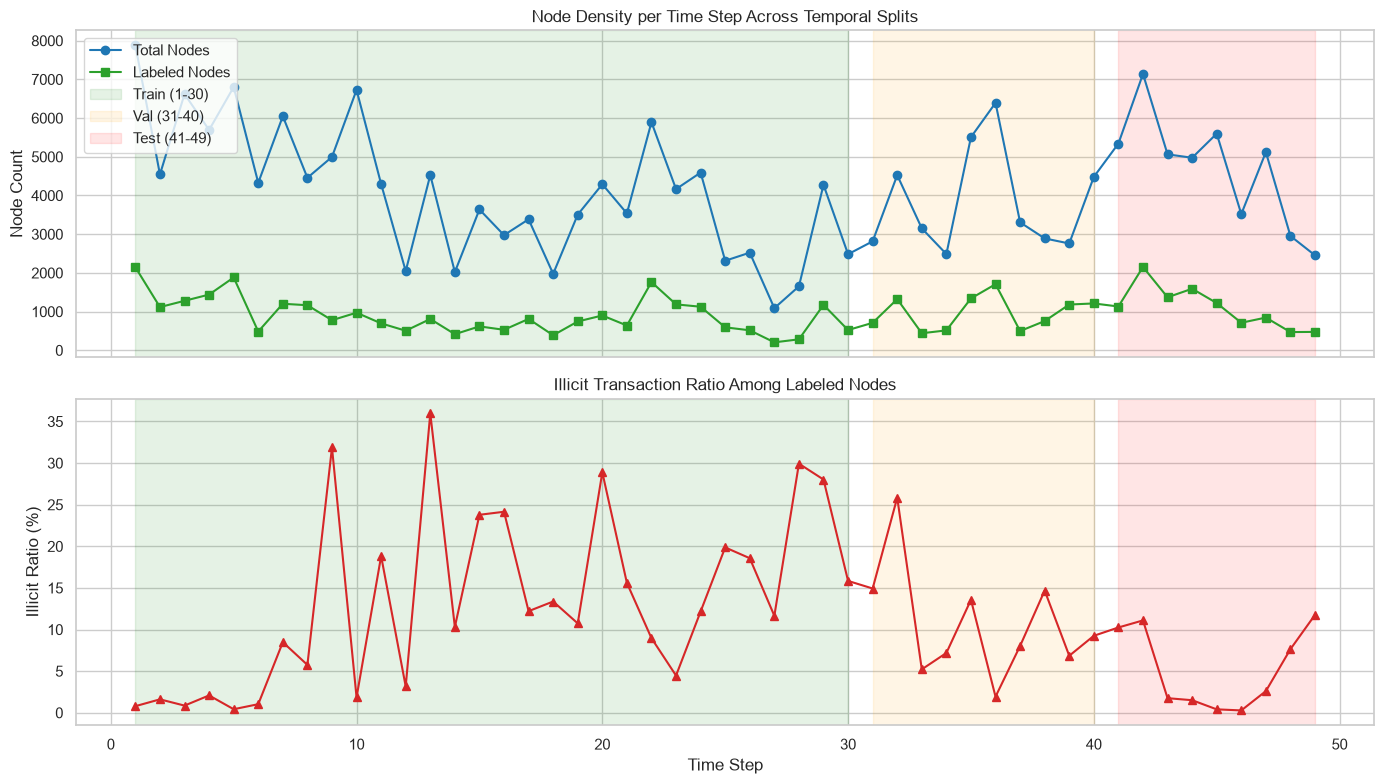

Figure saved to: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/outputs/figures/temporal_distribution.png

Flagged Outlier Time Steps (+/- 2 Std Dev):


,time_step,total_nodes,labeled_nodes,illicit_ratio
0,1,7880,2147,0.007918
41,42,7140,2154,0.110956


In [14]:
# Load split boundaries dynamically from config
train_start, train_end = config["dataset"]["train_time_steps"]
val_start, val_end = config["dataset"]["val_time_steps"]
test_start, test_end = config["dataset"]["test_time_steps"]

df_temporal = df_features[["tx_id", "time_step"]].merge(df_classes, on="tx_id")

assert len(df_temporal) == len(df_features), (
    f"Merge produced {len(df_temporal)} rows, expected {len(df_features)}; "
    "tx_id mismatch between features and classes files."
)

temporal_summary = df_temporal.groupby("time_step").agg(
    total_nodes=("class_label", "count"),
    labeled_nodes=("class_label", lambda x: x.isin(["licit", "illicit"]).sum()),
    illicit_nodes=("class_label", lambda x: (x == "illicit").sum()),
    licit_nodes=("class_label", lambda x: (x == "licit").sum())
).reset_index()

temporal_summary["illicit_ratio"] = (
    temporal_summary["illicit_nodes"] / temporal_summary["labeled_nodes"]
)

# Plotting node density and illicit ratio across time steps
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 1. Total vs Labeled Node Counts
axes[0].plot(temporal_summary["time_step"], temporal_summary["total_nodes"], label="Total Nodes", marker="o", color="#1f77b4")
axes[0].plot(temporal_summary["time_step"], temporal_summary["labeled_nodes"], label="Labeled Nodes", marker="s", color="#2ca02c")
axes[0].axvspan(train_start, train_end, color="green", alpha=0.1, label=f"Train ({train_start}-{train_end})")
axes[0].axvspan(val_start, val_end, color="orange", alpha=0.1, label=f"Val ({val_start}-{val_end})")
axes[0].axvspan(test_start, test_end, color="red", alpha=0.1, label=f"Test ({test_start}-{test_end})")
axes[0].set_ylabel("Node Count")
axes[0].set_title("Node Density per Time Step Across Temporal Splits")
axes[0].legend(loc="upper left")

# 2. Illicit Ratio
axes[1].plot(temporal_summary["time_step"], temporal_summary["illicit_ratio"] * 100, marker="^", color="#d62728")
axes[1].axvspan(train_start, train_end, color="green", alpha=0.1)
axes[1].axvspan(val_start, val_end, color="orange", alpha=0.1)
axes[1].axvspan(test_start, test_end, color="red", alpha=0.1)
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Illicit Ratio (%)")
axes[1].set_title("Illicit Transaction Ratio Among Labeled Nodes")

plt.tight_layout()
fig_save_path = FIGURES_DIR / "temporal_distribution.png"
plt.savefig(fig_save_path, dpi=200)
plt.show()
print(f"Figure saved to: {fig_save_path}")

# Identify outlier steps (labeled node count > 2 standard deviations away from the mean)
mean_nodes = temporal_summary["labeled_nodes"].mean()
std_nodes = temporal_summary["labeled_nodes"].std()
anomalies = temporal_summary[
    (temporal_summary["labeled_nodes"] < mean_nodes - 2 * std_nodes) |
    (temporal_summary["labeled_nodes"] > mean_nodes + 2 * std_nodes)
]

print("\nFlagged Outlier Time Steps (+/- 2 Std Dev):")
display(anomalies[["time_step", "total_nodes", "labeled_nodes", "illicit_ratio"]])

**Findings:** Node density per time step varies substantially, from roughly 2,000 to nearly 7,900 total nodes, with labeled node counts following a similar but noisier pattern. The illicit ratio among labeled nodes is highly volatile across time, ranging from under 1% to approximately 36%, which is direct empirical evidence of population drift along the temporal axis and reinforces the necessity of a temporal, rather than random, train/validation/test split. Time steps 1 and 42 were flagged as statistical outliers in labeled node count (beyond two standard deviations from the mean); these are noted for awareness during Phase 1 evaluation but are not excluded from the dataset, since exclusion would require independent justification beyond a simple density outlier.

## 4. Feature Schema Inspection

The 165 node features are documented as split into two groups: the first 93 are local transaction features computable from information available at the time the transaction entered the network, and the remaining 72 are aggregated features derived from each node's immediate neighbors.

Note on feature counting convention: the original Weber et al. (2019) paper describes this split as 94 local plus 72 aggregated (166 total), where the time step itself is counted as one of the 94 local features. In this notebook, `time_step` was separated into its own column prior to the `feat_1...feat_165` slice, so the local group here numbers 93 rather than 94. This is a labeling-convention difference, not a data discrepancy; the underlying 165-column feature matrix is identical either way, and this offset must be stated explicitly if the local/aggregated split is referenced in the portfolio write-up.

This split has implications for later feature engineering (aggregated features already encode one hop of graph structure, which is relevant when deciding how much additional aggregation GraphSAGE should perform). This section verifies dtypes, checks for unexpected non-numeric values, and profiles memory footprint given the fixed CPU deployment constraint.

In [15]:
feature_cols = [c for c in df_features.columns if c.startswith("feat_")]

# Ensure numeric parse integrity
non_numeric = [c for c in feature_cols if not np.issubdtype(df_features[c].dtype, np.number)]
if non_numeric:
    print(f"WARNING: Non-numeric columns detected: {non_numeric}")
else:
    print(f"All {len(feature_cols)} feature columns verified as numeric.")

# Partition into local (1-93) and aggregated (94-165) features
local_feats = feature_cols[:93]
agg_feats = feature_cols[93:]
print(f"Local features count:      {len(local_feats)} (feat_1 to feat_93)")
print(f"Aggregated features count: {len(agg_feats)} (feat_94 to feat_{len(feature_cols)})")

# Memory consumption footprint
mem_bytes = df_features.memory_usage(deep=True).sum()
print(f"\nDataFrame memory consumption: {mem_bytes / (1024 ** 2):.2f} MB")
print("Data type breakdown:")
print(df_features.dtypes.value_counts())

All 165 feature columns verified as numeric.
Local features count:      93 (feat_1 to feat_93)
Aggregated features count: 72 (feat_94 to feat_165)

DataFrame memory consumption: 258.85 MB
Data type breakdown:
float64    165
int64        1
int32        1
Name: count, dtype: int64


**Findings:** All 165 feature columns parsed as numeric with no failures. As implemented here, the local/aggregated split is 93 local (`feat_1` through `feat_93`) and 72 aggregated (`feat_94` through `feat_165`); see the counting-convention note above regarding the one-feature offset relative to the literature's 94/72 convention. Total in-memory footprint is 258.85 MB, well within the fixed CPU training budget.

## 5. Edge List Structural Validation

The edge list defines directed payment flows between transactions. This section must confirm: that every node ID referenced in the edge list also exists in the features file (an orphaned edge endpoint would break graph construction in Phase 1), the presence or absence of self-loops, and the presence or absence of duplicate edges. Each of these anomalies, if present, requires an explicit handling decision before Phase 1, not a silent default.

In [16]:
feature_node_ids = set(df_features["tx_id"])
edge_node_ids = set(df_edges["source"]).union(set(df_edges["target"]))

# Check for orphan endpoints in edge list
orphaned_ids = edge_node_ids - feature_node_ids
print(f"Orphaned edge endpoints: {len(orphaned_ids)}")
assert len(orphaned_ids) == 0, f"Integrity Failure: {len(orphaned_ids)} node IDs in edge list missing from features!"
print("Graph structural integrity passed: All edge endpoints exist in the features file.")

# Check for self-loops
self_loops = (df_edges["source"] == df_edges["target"]).sum()
print(f"Self-loop edge count: {self_loops}")

# Check for duplicate edges
duplicate_edges = df_edges.duplicated().sum()
print(f"Duplicate edge count: {duplicate_edges}")

Orphaned edge endpoints: 0
Graph structural integrity passed: All edge endpoints exist in the features file.
Self-loop edge count: 0
Duplicate edge count: 0


**Findings:** Zero orphaned edge endpoints, zero self-loops, and zero duplicate edges were found. The edge list is structurally clean; no special-case handling is required before Phase 1 graph construction.

## 6. Node Reindexing Plan

Raw transaction IDs are large, non-contiguous integers and are not suitable as direct tensor indices for PyTorch Geometric, which expects contiguous zero-based node indices. This section establishes the mapping strategy from raw `tx_id` to a contiguous index space, and confirms the mapping will be persisted as an artifact (not regenerated ad hoc in later notebooks), since any inconsistency between the mapping used for features, labels, and edges would silently corrupt the graph structure without raising an error.

In [17]:
# Construct contiguous zero-based index mapping for PyG
unique_tx_ids = df_features["tx_id"].values
node_mapping = pd.DataFrame({
    "tx_id": unique_tx_ids,
    "node_idx": np.arange(len(unique_tx_ids), dtype=np.int64)
})

# Save mapping artifact as CSV
mapping_path = DATA_PROCESSED / "node_id_mapping.csv"
node_mapping.to_csv(mapping_path, index=False)

print(f"Successfully mapped {len(node_mapping)} transaction IDs to contiguous indices [0, {len(node_mapping) - 1}].")
print(f"Mapping artifact saved to: {mapping_path}")
display(node_mapping.head())

Successfully mapped 203769 transaction IDs to contiguous indices [0, 203768].
Mapping artifact saved to: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/data/processed/node_id_mapping.csv


,tx_id,node_idx
0,230425980,0
1,5530458,1
2,232022460,2
3,232438397,3
4,230460314,4


**Findings:** All 203,769 `tx_id` values were successfully mapped to a contiguous index range [0, 203768] and persisted to `data/processed/node_id_mapping.csv`. CSV was chosen over Parquet for this specific artifact: the mapping is a two-column integer table with no dtype-ambiguity risk on round-trip, so the compression and schema-preservation advantages of Parquet do not materially apply here, and introducing a `pyarrow` dependency solely for this artifact was judged unnecessary. This decision should be revisited when persisting the larger processed feature matrix in Phase 1, where Parquet's advantages become concrete.

## 7. Missing Value and Anomaly Scan

A final systematic scan for missing values, sentinel values (e.g. -1 used as a placeholder within otherwise continuous feature columns), and any other irregularity not already surfaced by the previous sections.

In [18]:
# Null / NaN scan
null_counts = df_features[feature_cols].isnull().sum()
total_nulls = null_counts.sum()
print(f"Total NaN/Null entries across features: {total_nulls}")

# Infinite values scan
inf_count = np.isinf(df_features[feature_cols].to_numpy()).sum()
print(f"Total Infinite (inf) entries across features: {inf_count}")

# Value range inspection
feat_min = df_features[feature_cols].min().min()
feat_max = df_features[feature_cols].max().max()
print(f"Feature domain ranges: Min = {feat_min:.4f} | Max = {feat_max:.4f}")

if total_nulls == 0 and inf_count == 0:
    print("\nScan complete: Dataset is free of missing or corrupt numerical values.")

Total NaN/Null entries across features: 0
Total Infinite (inf) entries across features: 0
Feature domain ranges: Min = -13.0934 | Max = 289.2044

Scan complete: Dataset is free of missing or corrupt numerical values.


**Findings:** Zero null/NaN entries and zero infinite values were found across all 165 feature columns. The feature domain range, from -13.09 to 289.20, is asymmetric and includes negative values, which is inconsistent with raw, untransformed blockchain quantities (transaction counts, fees, and volumes are non-negative by construction). This is corroborated by external verification in Section 8: the feature matrix has already been z-score standardized by the dataset creators prior to release.

## 8. Summary and Handoff to Phase 1

**Dataset integrity.** All three raw files match their documented statistics exactly: 203,769 nodes, 234,355 edges, 165 node features. No missing values, infinite values, orphaned edge endpoints, self-loops, or duplicate edges were found anywhere in the dataset.

**Class distribution.** 77.15% of nodes are unknown, 20.62% licit, 2.23% illicit overall; within the labeled subset, 90.24% licit versus 9.76% illicit. This confirms both the extreme label scarcity and the extreme class imbalance the project is designed around, and directly supports the transductive message-passing decision already fixed in `configs/config.yaml`.

**Temporal structure.** Node density and, more importantly, the illicit ratio among labeled nodes vary substantially across the 49 time steps (illicit ratio ranging from under 1% to approximately 36%). This is direct evidence of population drift over time and confirms that a temporal split, rather than a random split, is methodologically necessary for this dataset. Two time steps (1 and 42) were flagged as density outliers and are noted for awareness rather than exclusion.

**Feature schema.** The 165 features split, as implemented, into 93 local and 72 aggregated columns; this differs from the literature's 94/72 convention only in whether `time_step` is counted separately, and this offset is documented in Section 4 to avoid ambiguity if compared against published work.

**Two externally verified facts requiring a Phase 1 decision.** During verification of a claim about feature normalization, cross-referencing multiple independent academic sources (the original Weber et al. 2019 dataset description and a 2026 reproducibility study) established two facts not derivable from this dataset's files alone:

1. All features except `time_step` are already z-score standardized (zero mean, unit variance) by the dataset creators prior to release. This directly affects the Phase 1 scaling decision: applying `RobustScaler` on top of already-standardized data must be a deliberate, explicitly justified choice, not a default carried over from the fraud detection project's pipeline convention.
2. The same reproducibility study reports that certain address-scoped aggregated features are computed relative to a single fixed reference point, Bitcoin block height 575,059, rather than to each transaction's own point in time. Because this reference point is identical across all 49 time steps, it introduces a systematic temporal leakage that is baked into the released dataset itself, upstream of any decision made in this project. This is not a defect introduced by this pipeline, but it must be explicitly disclosed as a documented limitation of the benchmark dataset in the portfolio write-up; omitting it would misrepresent how clean the input signal actually is, in direct conflict with this project's no-placeholder-metrics principle.

**Open items before Phase 1:**
- Decide whether additional scaling is applied given that features are already standardized, and document the justification either way in `configs/config.yaml`.
- Decide how to disclose the fixed-reference-block leakage in the portfolio write-up.
- Update the `model` and `training` sections of `configs/config.yaml` informed by these findings before graph construction begins.